In [1]:
import os
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
run_name = "ch12_sft-lora"

data_dir = Path("data") / "ch12" / "sft-lora"
tsv = data_dir / "training.tsv"

In [3]:
df = pd.read_csv(tsv, sep='\t')
df = df.sort_values(by='step', ascending=True)
df = df.drop_duplicates(subset=['step', 'split'], keep='last')

train_df = df.loc[df['split'] == 'train', :]
eval_df = df.loc[df['split'] == 'eval', :]

df.nsmallest(10, 'loss')

,step,epoch,split,loss,learning_rate,created_at
122,4950,108,train,6.203,0.0001,2025-10-01T11:15:11%:z
120,4850,106,train,6.206,0.0001,2025-10-01T11:09:34%:z
123,5000,109,train,6.206,0.0001,2025-10-01T11:17:59%:z
116,4700,103,train,6.207,0.0001,2025-10-01T11:01:05%:z
113,4600,101,train,6.210,0.0001,2025-10-01T10:55:25%:z
118,4800,105,train,6.210,0.0001,2025-10-01T11:06:42%:z
121,4900,107,train,6.210,0.0001,2025-10-01T11:12:22%:z
111,4500,98,train,6.212,0.0001,2025-10-01T10:49:49%:z
112,4550,99,train,6.212,0.0001,2025-10-01T10:52:37%:z
117,4750,104,train,6.212,0.0001,2025-10-01T11:03:54%:z


In [4]:
train_df.tail(10)

,step,epoch,split,loss,learning_rate,created_at
112,4550,99,train,6.212,0.0001,2025-10-01T10:52:37%:z
113,4600,101,train,6.210,0.0001,2025-10-01T10:55:25%:z
115,4650,102,train,6.213,0.0001,2025-10-01T10:58:17%:z
116,4700,103,train,6.207,0.0001,2025-10-01T11:01:05%:z
117,4750,104,train,6.212,0.0001,2025-10-01T11:03:54%:z
118,4800,105,train,6.210,0.0001,2025-10-01T11:06:42%:z
120,4850,106,train,6.206,0.0001,2025-10-01T11:09:34%:z
121,4900,107,train,6.210,0.0001,2025-10-01T11:12:22%:z
122,4950,108,train,6.203,0.0001,2025-10-01T11:15:11%:z
123,5000,109,train,6.206,0.0001,2025-10-01T11:17:59%:z


In [5]:
eval_df.tail(10)

,step,epoch,split,loss,learning_rate,created_at
79,3200,70,eval,6.698,NaN,2025-10-01T08:34:06%:z
84,3400,74,eval,6.707,NaN,2025-10-01T08:45:23%:z
89,3600,79,eval,6.695,NaN,2025-10-01T08:56:39%:z
94,3800,83,eval,6.696,NaN,2025-10-01T09:07:55%:z
99,4000,87,eval,6.692,NaN,2025-10-01T09:19:12%:z
104,4200,92,eval,6.690,NaN,2025-10-01T10:32:55%:z
109,4400,96,eval,6.693,NaN,2025-10-01T10:44:12%:z
114,4600,101,eval,6.692,NaN,2025-10-01T10:55:28%:z
119,4800,105,eval,6.679,NaN,2025-10-01T11:06:46%:z
124,5000,109,eval,6.683,NaN,2025-10-01T11:18:03%:z


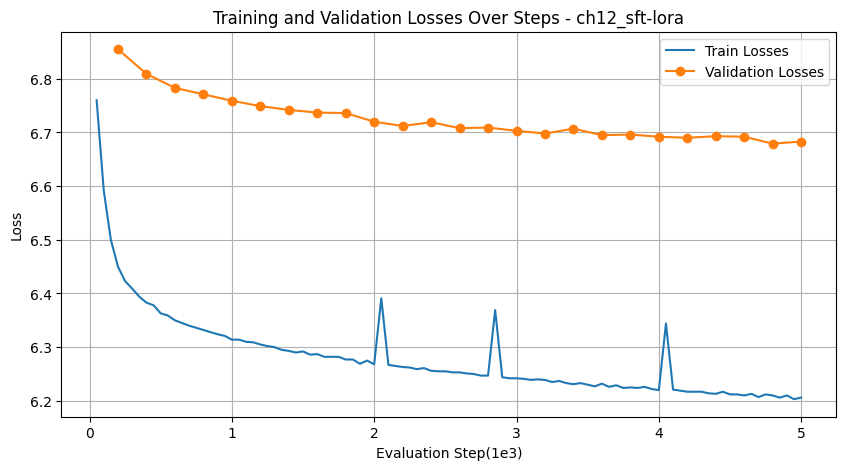

In [6]:
plt.figure(figsize=(10, 5))
plt.plot(train_df['step']/1e3, train_df['loss'], label="Train Losses")
plt.plot(eval_df['step']/1e3, eval_df['loss'], label="Validation Losses", marker='o')
plt.xlabel("Evaluation Step(1e3)")
plt.ylabel("Loss")
#plt.xlim(0, max(1e6, df["step"].max()))

plt.title(f"Training and Validation Losses Over Steps - {run_name}")
plt.legend()
plt.grid()

#plt.show()
plt.savefig(data_dir / "training.pdf")

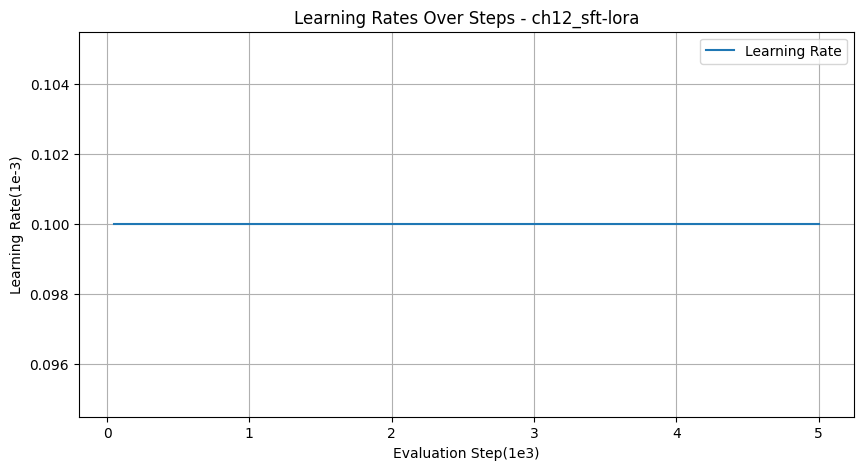

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(train_df['step']/1e3, train_df['learning_rate']*1e3, label="Learning Rate")
plt.xlabel("Evaluation Step(1e3)")
plt.ylabel("Learning Rate(1e-3)")
plt.title(f"Learning Rates Over Steps - {run_name}")
plt.legend()
plt.grid()
#plt.xlim(0, max(1e6, df["step"].max()))
#plt.show()
plt.savefig(data_dir / "learning_rate.pdf")